

    UNLABELED SINGLE MANUFACTURING CYCLE (Snapshot)
                                     │
                  ┌──────────────────┴──────────────────┐
                  │                                     │
                View 1                                View 2
          (Available Sensors)                    (Masked Sensors)
                  │                                     │
                  ↓                                     ↓
          Shared MLP Encoder                    Shared MLP Encoder
                  │                                     │
                  ↓                                     ↓
          z1 (Context Embedding)                z2 (Target Embedding)
                  │                                     │
                  ↓                                     │
            LeJEPA Predictor                            │
                  │                                     │
                  ↓                                     │
    z2_pred (Predicted Target Embedding)                │ (Stop-Gradient applied)
                  │                                     │
                  └──────────────────┬──────────────────┘
                                     ↓
                            Invariance + SIGReg
                    (Loss: MSE + Variance Regularization)
                                      │
                      ┌───────────────┴───────────────┐
                      ↓                               ↓
              Active Learning                  Explainability
      (Distance between z2 and z2_pred)    SHAP / Intra-cycle SCM
              Few labels queried              Root-cause mapping
                      │                               │
                      ↓                               ↓
            Quality Classification          Interpretable Reports
              (PassOrFail Target)        (Concurrent sensor effects)

## Imports and Data Preprocessing
This cell handles loading the dataset, dropping non-sensor metadata, handling class imbalance conceptually, and converting the raw features into standardized PyTorch tensors.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc




c:\Users\Iman\Desktop\CIRP Conference Study\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# CELL 1: Data Preprocessing
# ==========================================

# 1. Load the dataset
df = pd.read_csv('../data/labeled_data_preprocessed.csv')

# 2. Separate features and target, dropping metadata and null-heavy columns
features_to_drop = ['_id', 'TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD', 'EQUIP_NAME', 'Reason', 'PassOrFail']

X = df.drop(columns=features_to_drop)
y = df['PassOrFail'].values
feature_names = X.columns.tolist()

# 3. Standardize the features (Critical for isotropic regularization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Convert to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

print(f"Dataset Loaded. Shape: {X_tensor.shape}")
print(f"Total Defects (PassOrFail=1): {sum(y)} out of {len(y)}")

Dataset Loaded. Shape: torch.Size([5232, 26])
Total Defects (PassOrFail=1): 60 out of 5232


<br> <br> <br>

## Cell 2: Intra-Cycle LeJEPA Architecture

This defines the simple, shared Multi-Layer Perceptron (MLP) encoder and the predictor network, along with the Sketched Isotropic Gaussian Regularization (SIGReg) loss function.

In [3]:
# ==========================================
# CELL 2: LeJEPA Model Definition
# ==========================================
class LeJEPAEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()
        # Permutation-invariant MLP for intra-cycle features
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        
    def forward(self, x):
        return self.net(x)

class LeJEPAPredictor(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        
    def forward(self, z):
        return self.net(z)

def sigreg_loss(z_target, z_pred, variance_epsilon=1e-4):
    """
    Combines MSE prediction loss with variance regularization 
    to prevent latent space collapse (enforcing isotropic Gaussian).
    """
    # 1. Prediction error
    mse_loss = torch.mean((z_target - z_pred)**2)
    
    # 2. Variance regularization across the batch for the target embeddings
    var_z = torch.var(z_target, dim=0)
    std_loss = torch.mean(torch.relu(1 - var_z + variance_epsilon))
    
    # Combine with a weighting factor (hyperparameter to tune)
    return mse_loss + 0.1 * std_loss

<br> <br> <br>

## Cell 3: Self-Supervised Pre-training (Feature Masking)


This cell executes the intra-cycle masking. We randomly drop out roughly 50% of the sensors to create View 1 (the context) and use the complementary sensors as View 2 (the target), training the model to predict the missing physics of the cycle.

In [4]:
# ==========================================
# CELL 3: Intra-Cycle Pre-training 
# ==========================================
input_dim = X_tensor.shape[1]
latent_dim = 32

encoder = LeJEPAEncoder(input_dim, latent_dim)
predictor = LeJEPAPredictor(latent_dim)
optimizer = optim.Adam(list(encoder.parameters()) + list(predictor.parameters()), lr=1e-3)

epochs = 500 
batch_size = 256
dataset = torch.utils.data.TensorDataset(X_tensor)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

encoder.train()
predictor.train()

print("Starting LeJEPA Pre-training...")
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch in dataloader:
        x_batch = batch[0]
        optimizer.zero_grad()
        
        # Intra-cycle Feature Masking: Randomly mask ~50% of sensors
        mask = (torch.rand_like(x_batch) > 0.5).float()
        
        # View 1: Available context
        view1 = x_batch * mask
        # View 2: The missing features we want to predict
        view2 = x_batch * (1 - mask)
        
        # Encode both views
        z1 = encoder(view1)
        z2 = encoder(view2)
        
        # Predict View 2's latent state from View 1's latent state
        z2_pred = predictor(z1)
        
        # Calculate loss (detach z2 to stop gradients flowing through the target branch)
        loss = sigreg_loss(z2.detach(), z2_pred)
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    if (epoch + 1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(dataloader):.4f}")

print("Pre-training complete.")

Starting LeJEPA Pre-training...
Epoch [25/500], Loss: 0.0983
Epoch [50/500], Loss: 0.0650
Epoch [75/500], Loss: 0.0566
Epoch [100/500], Loss: 0.0517
Epoch [125/500], Loss: 0.0416
Epoch [150/500], Loss: 0.0395
Epoch [175/500], Loss: 0.0404
Epoch [200/500], Loss: 0.0385
Epoch [225/500], Loss: 0.0369
Epoch [250/500], Loss: 0.0379
Epoch [275/500], Loss: 0.0342
Epoch [300/500], Loss: 0.0344
Epoch [325/500], Loss: 0.0396
Epoch [350/500], Loss: 0.0334
Epoch [375/500], Loss: 0.0318
Epoch [400/500], Loss: 0.0302
Epoch [425/500], Loss: 0.0307
Epoch [450/500], Loss: 0.0282
Epoch [475/500], Loss: 0.0315
Epoch [500/500], Loss: 0.0308
Pre-training complete.


#### Note

Calling `encoder.train()` and `predictor.train()` sets the internal `training` flag of both modules (and all their child submodules) to `True` . This informs layers whose forward behavior changes between training and inference to activate their training-time mechanics .

## Behavior Toggled by `train()`
Calling `.train()` does not itself execute forward passes, compute gradients, or update weights . Instead, it toggles how specific layer types process data:

- **Dropout** (`nn.Dropout`): Randomly zeroes activations based on the specified dropout probability to regularize feature learning . In evaluation mode (`.eval()`), dropout passes activations through unchanged .
- **Batch Normalization** (`nn.BatchNorm1d` / `BatchNorm2d`): Computes mean and variance over the current mini-batch to normalize activations, while simultaneously updating its running mean and variance buffers via exponential moving averages . In evaluation mode, it freezes running statistics and normalizes inputs using those saved values .
- **Custom Modules**: Any custom module in `LeJEPAEncoder` or `LeJEPAPredictor` checking `self.training` can branch its internal logic dynamically based on this state .

## Training vs Evaluation Mode

| Component | `model.train()` (Default) | `model.eval()` |
| :--- | :--- | :--- |
| **Module Attribute** | `self.training = True`  | `self.training = False`  |
| **Dropout** | Drops activations randomly  | Deterministic identity pass  |
| **Batch Normalization** | Uses current batch stats and updates running buffers  | Uses frozen running stats  |
| **Gradient Tracking** | Unaffected (governed by `torch.set_grad_enabled`)  | Unaffected (still tracks unless wrapped in `torch.no_grad()`)  |

## Necessity in Your Pipeline
In PyTorch, newly instantiated subclasses of `nn.Module` initialize with `self.training = True` by default . 

Calling `encoder.train()` and `predictor.train()` here is a defensive programming practice . If validation loops or evaluation passes using `encoder.eval()` or `predictor.eval()` precede this code cell, failing to switch them back to `.train()` would cause normalization and regularization layers to remain frozen in inference mode throughout pre-training .

<br> <br>

## Cell 4: Active Learning & Classification

Using the trained predictor, we measure the latent error (uncertainty) on the dataset. We simulate querying an expert for the labels of the top most uncertain samples, and train a classifier strictly on that small budget.

In [5]:
# ==========================================
# CELL 4: Active Learning Loop & Classification
# ==========================================
encoder.eval()
predictor.eval()

# 1. Calculate Latent Prediction Error (Uncertainty) across all data
with torch.no_grad():
    # We measure how well the model predicts the full latent state from a 50% masked state
    mask_eval = (torch.rand_like(X_tensor) > 0.5).float()
    v1_eval = X_tensor * mask_eval
    
    z_context = encoder(v1_eval)
    z_target = encoder(X_tensor) # The true latent representation of the full cycle
    z_pred = predictor(z_context)
    
    # Uncertainty is the L2 distance between predicted and actual latent state
    uncertainty_scores = torch.norm(z_target - z_pred, dim=1).numpy()

# 2. Active Learning Query (Simulating a human-in-the-loop budget of 300 cycles)
labeling_budget = 300
query_indices = np.argsort(uncertainty_scores)[-labeling_budget:]

X_active_learning = X_scaled[query_indices]
y_active_learning = y[query_indices]

print(f"Queried {labeling_budget} most uncertain samples.")
print(f"Defects found in queried subset: {sum(y_active_learning)}")

# 3. Train Classifier on the actively queried subset
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_active_learning, y_active_learning)

# 4. Evaluate on the remaining unqueried data
unqueried_indices = np.setdiff1d(np.arange(len(y)), query_indices)
y_pred = clf.predict(X_scaled[unqueried_indices])

print("\n--- Classification Report (Unqueried Data) ---")
print(classification_report(y[unqueried_indices], y_pred))

Queried 300 most uncertain samples.
Defects found in queried subset: 14

--- Classification Report (Unqueried Data) ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4886
           1       0.05      0.02      0.03        46

    accuracy                           0.99      4932
   macro avg       0.52      0.51      0.51      4932
weighted avg       0.98      0.99      0.98      4932



<br> <br>

## Cell 5: Explainability (SHAP)

This cell addresses the explainability requirement for the paper. It generates a SHAP summary plot mapping the classifier's decisions directly back to the concurrent physical sensor readings (e.g., identifying if Average_Back_Pressure caused the anomaly).

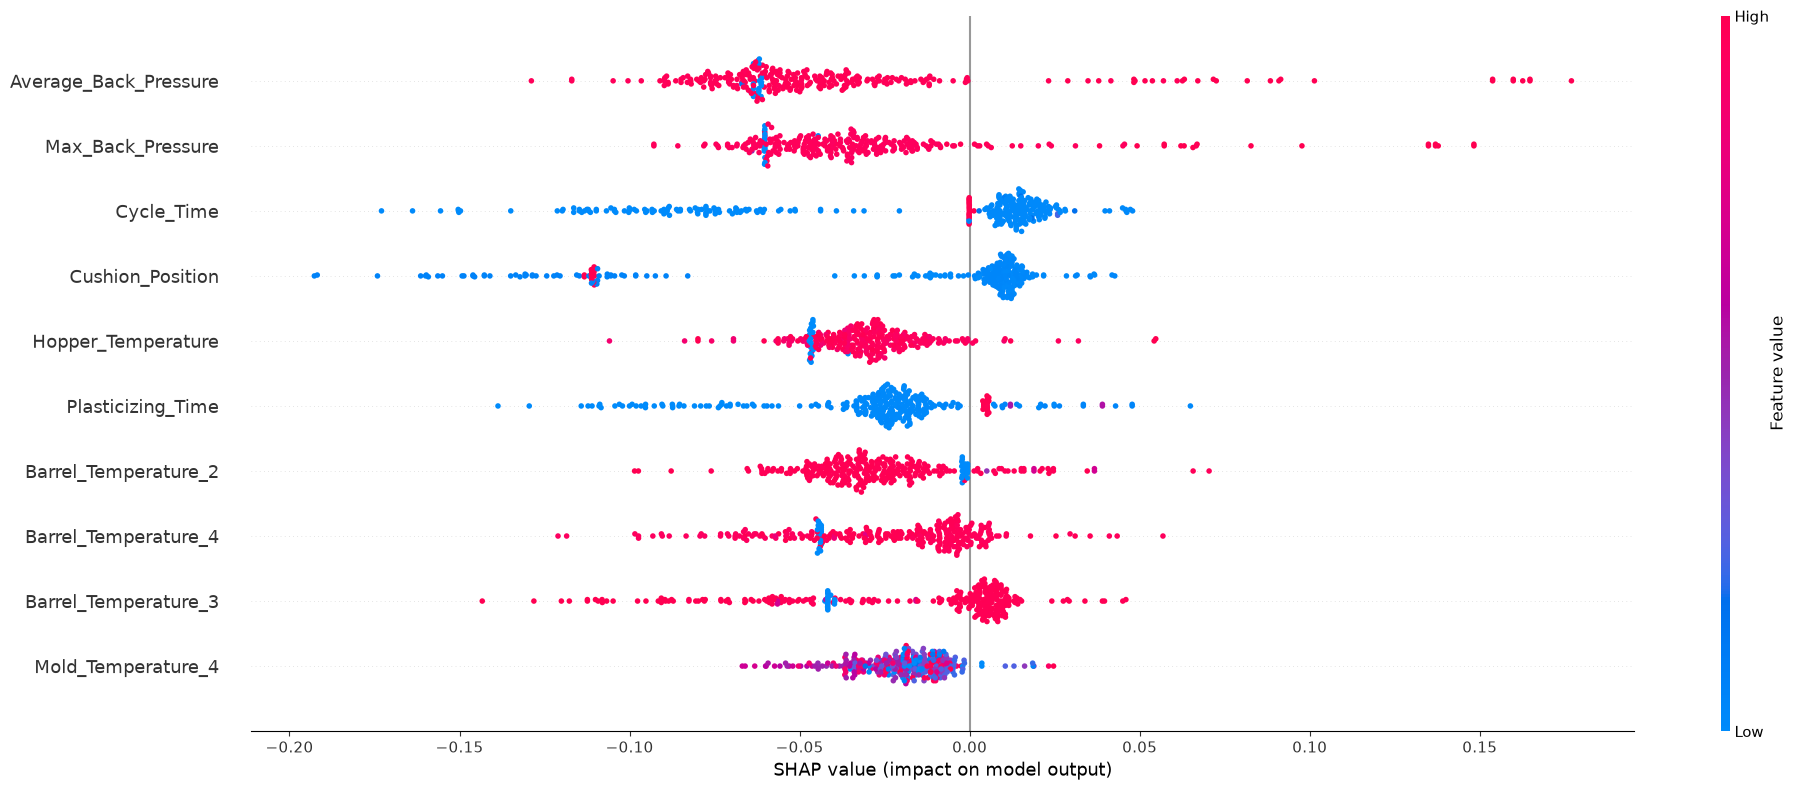

In [6]:
# ==========================================
# CELL 5: SHAP Explainability
# ==========================================
# We apply TreeExplainer to our Random Forest model to provide 
# physical root-cause explanations to the manufacturing operator.

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_active_learning)

# Normalise the SHAP output to a 2D (n_samples, n_features) matrix for the
# positive ("Fail") class. Older shap returns a list of per-class arrays, while
# shap >= 0.45 returns one (n_samples, n_features, n_classes) array.
if isinstance(shap_values, list):
    shap_values_to_plot = np.asarray(shap_values[1])
else:
    shap_values_to_plot = np.asarray(shap_values)
    if shap_values_to_plot.ndim == 3:
        shap_values_to_plot = shap_values_to_plot[:, :, 1]



# 1. Call the plot with show=False so it doesn't render yet
shap.summary_plot(
    shap_values_to_plot, 
    pd.DataFrame(X_active_learning, columns=feature_names), 
    max_display=10, 
    show=False
)

# 2. THE FIX: Grab the current figure and forcefully set its size in inches
fig = plt.gcf()
fig.set_size_inches(20,8) # Change width (12) and height (8) as needed

# 3. Add titles and render
# plt.title("Top Sensor Contributions to Anomalies (Intra-Cycle)\n\n\n")
plt.tight_layout()
plt.show()

Generating high-resolution SHAP beeswarm plot...


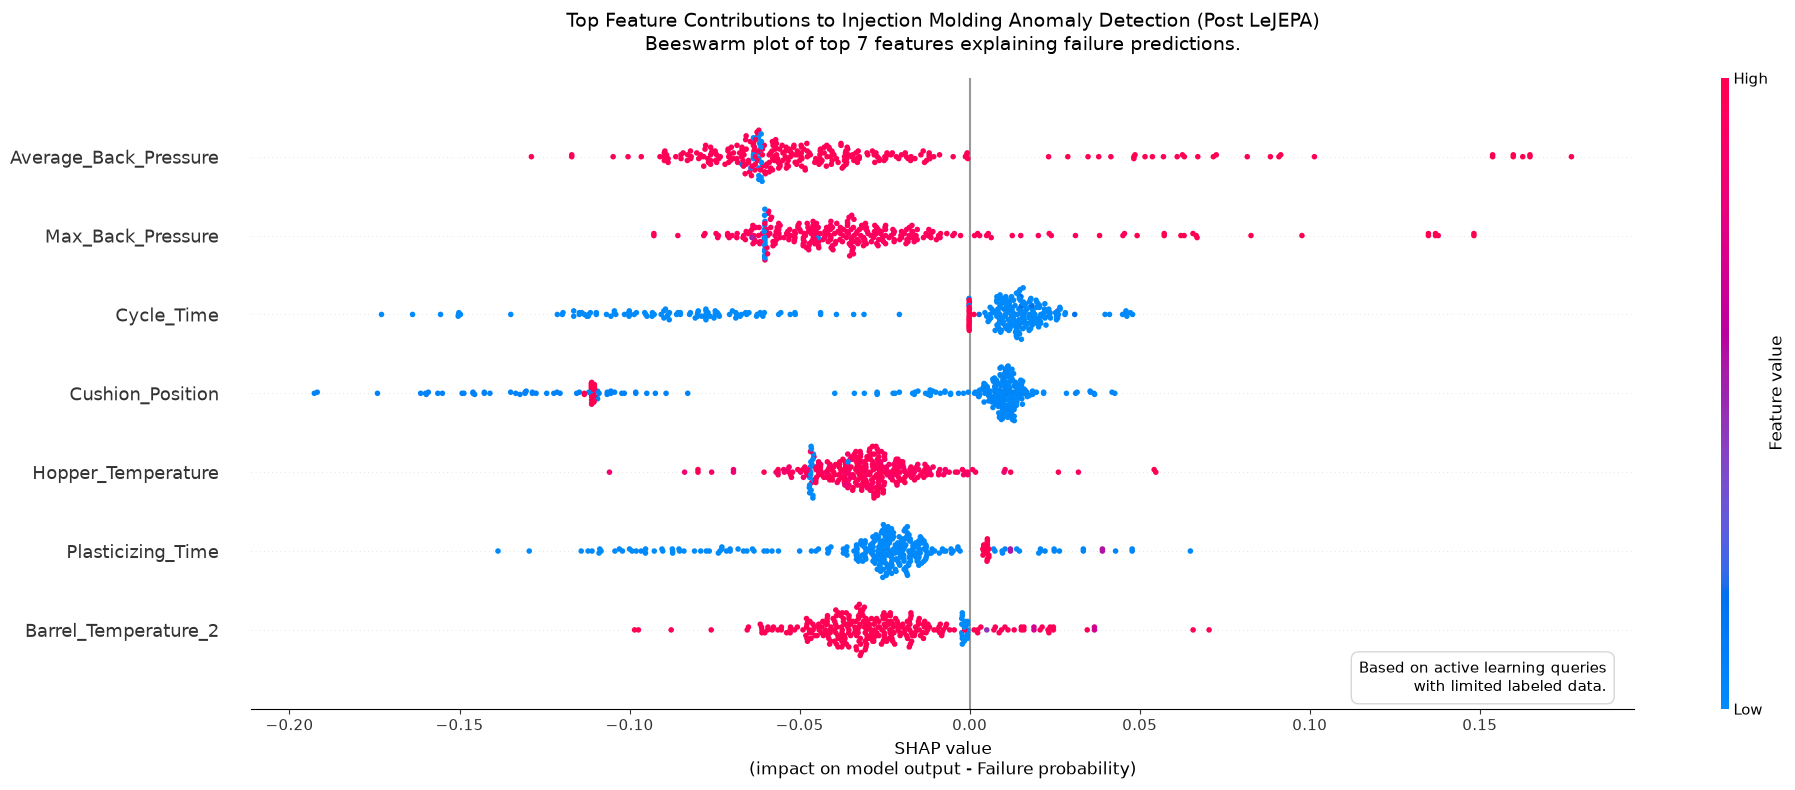

In [9]:
# ==========================================
# CELL 5: SHAP Explainability (Bulletproof Sizing)
# ==========================================
import matplotlib.pyplot as plt
import shap
import pandas as pd
import numpy as np

# 1. Initialize Explainer and calculate SHAP values
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_active_learning)

# Normalise the SHAP output to a 2D (n_samples, n_features) matrix for the
# positive ("Fail") class. Older shap returns a list of per-class arrays, while
# shap >= 0.45 returns one (n_samples, n_features, n_classes) array.
if isinstance(shap_values, list):
    shap_values_to_plot = np.asarray(shap_values[1])
else:
    shap_values_to_plot = np.asarray(shap_values)
    if shap_values_to_plot.ndim == 3:
        shap_values_to_plot = shap_values_to_plot[:, :, 1]

print("Generating high-resolution SHAP beeswarm plot...")

# 2. Force Matplotlib's global figure size (Double protection)
plt.rcParams['figure.figsize'] = [12, 8]
fig = plt.figure(figsize=(20, 8))
ax = plt.gca()

# 3. THE FIX: Set plot_size=None to stop SHAP from overriding the dimensions
shap.summary_plot(
    shap_values_to_plot, 
    pd.DataFrame(X_active_learning, columns=feature_names), 
    max_display=7, 
    plot_size=None,  # <--- This forces SHAP to respect our 12x8 figure size
    show=False
)

# 4. Add custom titles and labels
plt.title(
    "Top Feature Contributions to Injection Molding Anomaly Detection (Post LeJEPA)\n"
    "Beeswarm plot of top 7 features explaining failure predictions.", 
    fontsize=14, pad=20
)

ax.set_xlabel("SHAP value\n(impact on model output - Failure probability)", fontsize=12)

# 5. Add the active learning context text box
plt.text(
    0.98, 0.02, 
    "Based on active learning queries\nwith limited labeled data.", 
    horizontalalignment='right', 
    verticalalignment='bottom', 
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='lightgray', boxstyle='round,pad=0.5')
)

# 6. Final layout adjustments and render
plt.tight_layout()
plt.show()

# Reset rcParams back to default so it doesn't affect other notebook plots
plt.rcParams['figure.figsize'] = plt.rcParamsDefault['figure.figsize']

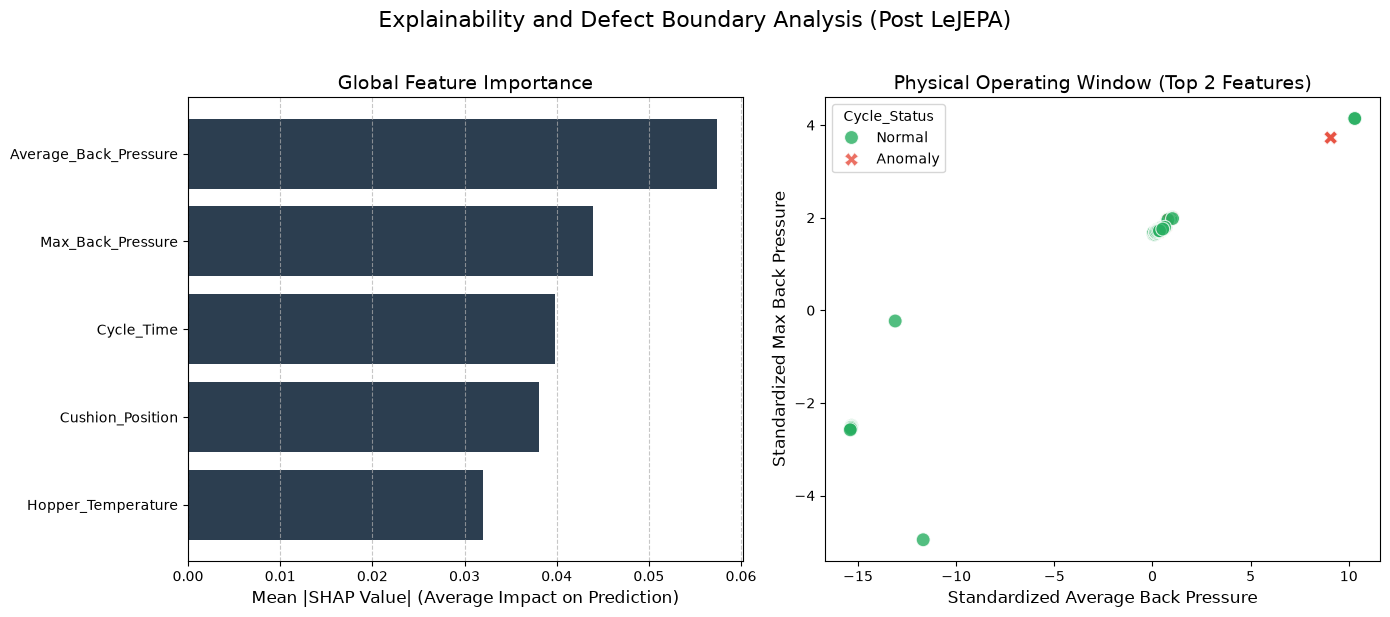

In [8]:
# ==========================================
# CELL 5: XAI & Operating Window (Dual Plot)
# ==========================================

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_active_learning)



# 1. Calculate Mean Absolute SHAP values for Global Importance
# (shap_values_to_plot is the 2D positive-class matrix built in the explainer cell)
shap_values_to_plot = np.asarray(shap_values_to_plot)
if shap_values_to_plot.ndim == 3:
    shap_values_to_plot = shap_values_to_plot[:, :, 1]

shap_abs_mean = np.abs(shap_values_to_plot).mean(axis=0)
assert shap_abs_mean.shape == (len(feature_names),), (
    f"Expected one importance per feature, got {shap_abs_mean.shape}"
)

# Rank the features and grab the top 5 for the bar chart
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': shap_abs_mean})
importance_df = importance_df.sort_values(by='Importance', ascending=True)
top5_df = importance_df.tail(5)

# The two most important features drive the operating-window scatter
feat_x, feat_y = importance_df['Feature'].iloc[-1], importance_df['Feature'].iloc[-2]

# 2. Prepare the DataFrame for the 2D Scatter Plot
X_al_df = pd.DataFrame(X_active_learning, columns=feature_names)
# Map 0 and 1 to readable labels for the legend
X_al_df['Cycle_Status'] = np.where(y_active_learning == 1, 'Anomaly', 'Normal')

# 3. Set up the Matplotlib figure with 2 subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT PLOT: SHAP Bar Chart ---
ax1.barh(top5_df['Feature'], top5_df['Importance'], color='#2C3E50')
ax1.set_xlabel('Mean |SHAP Value| (Average Impact on Prediction)', fontsize=12)
ax1.set_title('Global Feature Importance', fontsize=14)
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# --- RIGHT PLOT: 2D Operating Window ---
sns.scatterplot(
    data=X_al_df,
    x=feat_x,
    y=feat_y,
    hue='Cycle_Status',
    hue_order=['Normal', 'Anomaly'],
    palette={'Normal': '#27AE60', 'Anomaly': '#E74C3C'}, # Colorblind-friendly Green/Red
    style='Cycle_Status',
    markers={'Normal': 'o', 'Anomaly': 'X'},
    s=100, # Marker size
    alpha=0.8,
    ax=ax2
)

ax2.set_title('Physical Operating Window (Top 2 Features)', fontsize=14)
ax2.set_xlabel(f"Standardized {feat_x.replace('_', ' ')}", fontsize=12)
ax2.set_ylabel(f"Standardized {feat_y.replace('_', ' ')}", fontsize=12)

# 4. Final layout adjustments
plt.suptitle('Explainability and Defect Boundary Analysis (Post LeJEPA)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
